#### Задание

В домашнем задании нужно решить задачу классификации наличия болезни сердца у пациентов наиболее эффективно. Целевая переменная – наличие болезни сердца (HeartDisease). Она принимает значения 0 или 1 в зависимости от отсутствия или наличия болезни соответственно.

Этапы работы:
- Подготовьте датасет к обучению моделей:
a) Категориальные переменные переведите в цифровые значения. Можно использовать pd.get_dummies, preprocessing.LabelEncoder. Старайтесь не использовать для этой задачи циклы.
- Разделите выборку на обучающее и тестовое подмножество. 80% данных оставить на обучающее множество, 20% на тестовое.
- Обучите модель логистической регрессии с параметрами по умолчанию.
- Подсчитайте основные метрики модели. Используйте следующие метрики и функцию:
cross_validate(…, cv=10, scoring=[‘accuracy’,‘recall’,‘precision’,‘f1’])
- Оптимизируйте 3-4 параметра модели:
1. Используйте GridSearchCV.
2. Используйте RandomizedSearchCV.
3. *Добавьте в RandomizedSearchCV 2-5 моделей классификации и вариации их параметров.
4. Повторите cross_validate после каждого итогового изменения параметров.
- Сформулируйте выводы по проделанной работе:
1. Сравните метрики построенных моделей.
2. *Сравните с полученными результатами в домашнем задании по теме «Ансамблирование».

- https://scikit-learn.org/stable/modules/generated/sklearn.preprocessing.LabelEncoder.html
- https://pandas.pydata.org/docs/reference/api/pandas.get_dummies.html
- https://scikit-learn.org/stable/modules/generated/sklearn.model_selection.GridSearchCV.html
- https://scikit-learn.org/stable/modules/generated/sklearn.model_selection.RandomizedSearchCV.html

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
import pandas as pd
import numpy as np
from sklearn.preprocessing import LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import cross_val_score
from sklearn.model_selection import cross_validate
from sklearn.model_selection import GridSearchCV, RandomizedSearchCV
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.metrics import confusion_matrix

Функция `cross_validate` отличается от `cross_val_score`:

Возвращает метрики оценки и другую вспомогательную информацию, тогда как cross_val_score возвращает только метрики оценки.

Позволяет указать несколько метрик для оценки.

Она возвращает dict, содержащий fit-times, score-times (и опционально тренировочные баллы, обученные оценки, индексы разбиения тренировки и теста) в дополнение к тестовому баллу.

return_train_score по умолчанию имеет значение False для экономии времени вычислений. Чтобы оценить оценки и на обучающей выборке, необходимо установить значение True.

Также можно сохранить оценку, установленную на каждом обучающем наборе, установив return_estimator=True. Аналогично можно установить return_indices=True, чтобы сохранить индексы обучения и тестирования, используемые для разбиения набора данных на обучающий и тестовый наборы для каждого разбиения cv.

In [ ]:
df = pd.read_csv('heart.csv')
df.head(3)

,Age,Sex,ChestPainType,RestingBP,Cholesterol,FastingBS,RestingECG,MaxHR,ExerciseAngina,Oldpeak,ST_Slope,HeartDisease
0,40,M,ATA,140,289,0,Normal,172,N,0.0,Up,0
1,49,F,NAP,160,180,0,Normal,156,N,1.0,Flat,1
2,37,M,ATA,130,283,0,ST,98,N,0.0,Up,0


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 918 entries, 0 to 917
Data columns (total 12 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Age             918 non-null    int64  
 1   Sex             918 non-null    object 
 2   ChestPainType   918 non-null    object 
 3   RestingBP       918 non-null    int64  
 4   Cholesterol     918 non-null    int64  
 5   FastingBS       918 non-null    int64  
 6   RestingECG      918 non-null    object 
 7   MaxHR           918 non-null    int64  
 8   ExerciseAngina  918 non-null    object 
 9   Oldpeak         918 non-null    float64
 10  ST_Slope        918 non-null    object 
 11  HeartDisease    918 non-null    int64  
dtypes: float64(1), int64(6), object(5)
memory usage: 86.2+ KB


#### 2 вариант

In [ ]:
df.select_dtypes('object').head(3)

,Sex,ChestPainType,RestingECG,ExerciseAngina,ST_Slope
0,M,ATA,Normal,N,Up
1,F,NAP,Normal,N,Flat
2,M,ATA,ST,N,Up


In [ ]:
print(df.ChestPainType.unique())
print(df.RestingECG.unique())
print(df.ExerciseAngina.unique())
print(df.ST_Slope.unique())
print(df.Sex.unique())

['ATA' 'NAP' 'ASY' 'TA']
['Normal' 'ST' 'LVH']
['N' 'Y']
['Up' 'Flat' 'Down']
['M' 'F']


In [ ]:
df['Sex'] = LabelEncoder().fit_transform(df['Sex'])
df['ExerciseAngina'] = LabelEncoder().fit_transform(df['ExerciseAngina'])

In [ ]:
df = pd.get_dummies(df)

In [ ]:
x = df.drop(columns='HeartDisease')
y = df['HeartDisease']

In [ ]:
x_train, x_test, y_train, y_test = train_test_split(x, y, train_size=0.8, random_state=10)

In [ ]:
model = LogisticRegression(max_iter=10000)
model.fit(x_train, y_train)

LogisticRegression(max_iter=10000)

In [ ]:
result = model.score(x_test, y_test)
result

0.8478260869565217

In [ ]:
result_cv = cross_validate(model, x_test, y_test, cv=10, scoring=['accuracy','recall','precision','f1'])

In [ ]:
print('Accuracy =', round(result_cv['test_accuracy'].mean(),3))
print('Recall =', round(result_cv['test_recall'].mean(),3))
print('Precision =', round(result_cv['test_precision'].mean(),3))
print('F1 =', round(result_cv['test_f1'].mean(),3))

Accuracy = 0.832
Recall = 0.85
Precision = 0.844
F1 = 0.843


In [ ]:
y_pr = model.predict(x_test)

<Axes: >

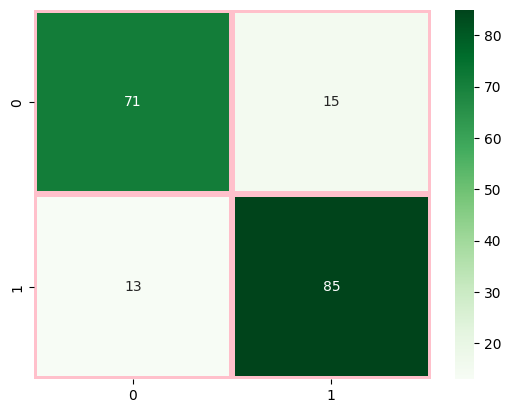

In [ ]:
conf = confusion_matrix(y_test, y_pr)
sns.heatmap(conf, annot=True, cmap='Greens', linewidth=3, linecolor='pink')

In [ ]:
params ={'tol':[0.0001, 0.001, 0.001],
         'C':[0.1, 0.3, 0.5,1.,2.,3.,5.,10.,15.,20.],
         'solver': ['lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga']}

In [ ]:
LR = LogisticRegression(max_iter=10000, random_state=10)
grid = GridSearchCV(LR, params, cv=5, scoring='accuracy', n_jobs=-1)

In [ ]:
grid.fit(x_train, y_train)

GridSearchCV(cv=5,
             estimator=LogisticRegression(max_iter=10000, random_state=10),
             n_jobs=-1,
             param_grid={'C': [0.1, 0.3, 0.5, 1.0, 2.0, 3.0, 5.0, 10.0, 15.0,
                               20.0],
                         'solver': ['lbfgs', 'liblinear', 'newton-cg',
                                    'newton-cholesky', 'sag', 'saga'],
                         'tol': [0.0001, 0.001, 0.001]},
             scoring='accuracy')

In [ ]:
print(grid.best_score_)
print(grid.best_params_)
print(grid.best_estimator_)

0.8691454664057403
{'C': 1.0, 'solver': 'liblinear', 'tol': 0.0001}
LogisticRegression(max_iter=10000, random_state=10, solver='liblinear')


In [ ]:
model_best = grid.best_estimator_.fit(x_train, y_train)
model_best.score(x_test, y_test)

0.8478260869565217

In [ ]:
result_cv_grid = cross_validate(model_best, x_test, y_test, cv=10, scoring=['accuracy','recall','precision','f1'])

In [ ]:
print('Accuracy =', round(result_cv_grid['test_accuracy'].mean(),3))
print('Recall =', round(result_cv_grid['test_recall'].mean(),3))
print('Precision =', round(result_cv_grid['test_precision'].mean(),3))
print('F1 =', round(result_cv_grid['test_f1'].mean(),3))

Accuracy = 0.849
Recall = 0.87
Precision = 0.857
F1 = 0.861


In [ ]:
rand = RandomizedSearchCV(LR, params, cv=5, scoring='accuracy')
rand.fit(x_train, y_train)

RandomizedSearchCV(cv=5,
                   estimator=LogisticRegression(max_iter=10000,
                                                random_state=10),
                   param_distributions={'C': [0.1, 0.3, 0.5, 1.0, 2.0, 3.0, 5.0,
                                              10.0, 15.0, 20.0],
                                        'solver': ['lbfgs', 'liblinear',
                                                   'newton-cg',
                                                   'newton-cholesky', 'sag',
                                                   'saga'],
                                        'tol': [0.0001, 0.001, 0.001]},
                   scoring='accuracy')

In [ ]:
print(rand.best_score_)
print(rand.best_params_)
print(rand.best_estimator_)

0.8677849221880534
{'tol': 0.001, 'solver': 'newton-cholesky', 'C': 0.1}
LogisticRegression(C=0.1, max_iter=10000, random_state=10,
                   solver='newton-cholesky', tol=0.001)


In [ ]:
model_rand = rand.best_estimator_.fit(x_train, y_train)
model_rand.score(x_test, y_test)

0.8641304347826086

In [ ]:
result_cv_rand = cross_validate(model_rand, x_test, y_test, cv=10, scoring=['accuracy','recall','precision','f1'])

In [ ]:
print('Accuracy =', round(result_cv_rand['test_accuracy'].mean(),3))
print('Recall =', round(result_cv_rand['test_recall'].mean(),3))
print('Precision =', round(result_cv_rand['test_precision'].mean(),3))
print('F1 =', round(result_cv_rand['test_f1'].mean(),3))

Accuracy = 0.828
Recall = 0.83
Precision = 0.846
F1 = 0.83


In [ ]:
rfc_params  = {'n_estimators': [30, 50, 100, 150, 200],
               'criterion': ['gini', 'entropy', 'log_loss'],
               'max_depth': [3, 5, 8, 10, 12, 15],
               'min_samples_leaf': [1, 3, 5, 7, 10]}

RFC = RandomForestClassifier(random_state=9)
rand_rfc = RandomizedSearchCV(RFC, rfc_params, cv=5, scoring='accuracy')
rand_rfc.fit(x_train, y_train)

print(rand_rfc.best_score_)
print(rand_rfc.best_params_)
print(rand_rfc.best_estimator_)

0.8800577765352717
{'n_estimators': 150, 'min_samples_leaf': 5, 'max_depth': 12, 'criterion': 'entropy'}
RandomForestClassifier(criterion='entropy', max_depth=12, min_samples_leaf=5,
                       n_estimators=150, random_state=9)


In [ ]:
rfc_rand = rand_rfc.best_estimator_.fit(x_train, y_train)
rfc_rand.score(x_test, y_test)

0.8369565217391305

In [ ]:
result_cv_rfc = cross_validate(rfc_rand, x_test, y_test, cv=10, scoring=['accuracy','recall','precision','f1'])

print('Accuracy =', round(result_cv_rfc['test_accuracy'].mean(),3))
print('Recall =', round(result_cv_rfc['test_recall'].mean(),3))
print('Precision =', round(result_cv_rfc['test_precision'].mean(),3))
print('F1 =', round(result_cv_rfc['test_f1'].mean(),3))

Accuracy = 0.865
Recall = 0.93
Precision = 0.844
F1 = 0.882


In [ ]:
kn_params  = {'n_neighbors': [3, 5, 8, 10, 15, 20],
               'weights': ['uniform', 'distance'],
               'p': [1, 2]}

KN = KNeighborsClassifier()
rand_kn = RandomizedSearchCV(KN, kn_params, cv=5, scoring='accuracy')
rand_kn.fit(x_train, y_train)

print(rand_kn.best_score_)
print(rand_kn.best_params_)
print(rand_kn.best_estimator_)

0.7547665641599105
{'weights': 'distance', 'p': 1, 'n_neighbors': 20}
KNeighborsClassifier(n_neighbors=20, p=1, weights='distance')


In [ ]:
kn_rand = rand_kn.best_estimator_.fit(x_train, y_train)
kn_rand.score(x_test, y_test)

0.7663043478260869

In [ ]:
result_cv_kn = cross_validate(kn_rand, x_test, y_test, cv=10, scoring=['accuracy','recall','precision','f1'])

print('Accuracy =', round(result_cv_kn['test_accuracy'].mean(),3))
print('Recall =', round(result_cv_kn['test_recall'].mean(),3))
print('Precision =', round(result_cv_kn['test_precision'].mean(),3))
print('F1 =', round(result_cv_kn['test_f1'].mean(),3))

Accuracy = 0.723
Recall = 0.623
Precision = 0.822
F1 = 0.702


In [ ]:
svc_params  = {'C': [0.1, 0.5, 1., 3., 5., 10.],
               'kernel': ['linear', 'poly', 'rbf', 'sigmoid'],
               'tol': [0.0001, 0.001, 0.01, 0.1]}

svc = SVC(random_state=99)
rand_svc = RandomizedSearchCV(svc, svc_params, cv=5, scoring='accuracy')
rand_svc.fit(x_train, y_train)

print(rand_svc.best_score_)
print(rand_svc.best_params_)
print(rand_svc.best_estimator_)

0.862361382909328
{'tol': 0.0001, 'kernel': 'linear', 'C': 3.0}
SVC(C=3.0, kernel='linear', random_state=99, tol=0.0001)


In [ ]:
svc_rand = rand_svc.best_estimator_.fit(x_train, y_train)
svc_rand.score(x_test, y_test)

0.8586956521739131

In [ ]:
result_cv_svc = cross_validate(svc_rand, x_test, y_test, cv=10, scoring=['accuracy','recall','precision','f1'])

print('Accuracy =', round(result_cv_svc['test_accuracy'].mean(),3))
print('Recall =', round(result_cv_svc['test_recall'].mean(),3))
print('Precision =', round(result_cv_svc['test_precision'].mean(),3))
print('F1 =', round(result_cv_svc['test_f1'].mean(),3))

Accuracy = 0.838
Recall = 0.86
Precision = 0.846
F1 = 0.85


In [ ]:
compares = pd.DataFrame({'LR':[round(result_cv['test_accuracy'].mean(),3), round(result_cv['test_recall'].mean(),3),
                                    round(result_cv['test_precision'].mean(),3), round(result_cv['test_f1'].mean(),3)],
                        'LR_grid':[round(result_cv_grid['test_accuracy'].mean(),3), round(result_cv_grid['test_recall'].mean(),3),
                                    round(result_cv_grid['test_precision'].mean(),3), round(result_cv_grid['test_f1'].mean(),3)],
                        'LR_random':[round(result_cv_rand['test_accuracy'].mean(),3), round(result_cv_rand['test_recall'].mean(),3),
                                      round(result_cv_rand['test_precision'].mean(),3), round(result_cv_rand['test_f1'].mean(),3)],
                        'RFC_random':[round(result_cv_rfc['test_accuracy'].mean(),3), round(result_cv_rfc['test_recall'].mean(),3),
                                       round(result_cv_rfc['test_precision'].mean(),3), round(result_cv_rfc['test_f1'].mean(),3)],
                        'KN_random':[round(result_cv_kn['test_accuracy'].mean(),3), round(result_cv_kn['test_recall'].mean(),3),
                                      round(result_cv_kn['test_precision'].mean(),3), round(result_cv_kn['test_f1'].mean(),3)],
                        'SVC_random':[round(result_cv_svc['test_accuracy'].mean(),3), round(result_cv_svc['test_recall'].mean(),3),
                                       round(result_cv_svc['test_precision'].mean(),3), round(result_cv_svc['test_f1'].mean(),3)]},
                       index=(['Accuracy', 'Recall', 'Precision', 'F1']))

compares

,LR,LR_grid,LR_random,RFC_random,KN_random,SVC_random
Accuracy,0.828,0.849,0.828,0.865,0.723,0.838
Recall,0.830,0.870,0.830,0.930,0.623,0.860
Precision,0.846,0.857,0.846,0.844,0.822,0.846
F1,0.830,0.861,0.830,0.882,0.702,0.850


#### 1 вариант

In [ ]:
df = pd.read_csv('heart.csv')

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 918 entries, 0 to 917
Data columns (total 12 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Age             918 non-null    int64  
 1   Sex             918 non-null    object 
 2   ChestPainType   918 non-null    object 
 3   RestingBP       918 non-null    int64  
 4   Cholesterol     918 non-null    int64  
 5   FastingBS       918 non-null    int64  
 6   RestingECG      918 non-null    object 
 7   MaxHR           918 non-null    int64  
 8   ExerciseAngina  918 non-null    object 
 9   Oldpeak         918 non-null    float64
 10  ST_Slope        918 non-null    object 
 11  HeartDisease    918 non-null    int64  
dtypes: float64(1), int64(6), object(5)
memory usage: 86.2+ KB


In [ ]:
data = pd.get_dummies(df.loc[:, ['Age', 'ChestPainType',	'RestingBP',	'Cholesterol',	'FastingBS',	'RestingECG',
                                 'MaxHR', 'Oldpeak',	'ST_Slope',	'HeartDisease']])

In [ ]:
data.head(3)

,Age,RestingBP,Cholesterol,FastingBS,MaxHR,Oldpeak,HeartDisease,ChestPainType_ASY,ChestPainType_ATA,ChestPainType_NAP,ChestPainType_TA,RestingECG_LVH,RestingECG_Normal,RestingECG_ST,ST_Slope_Down,ST_Slope_Flat,ST_Slope_Up
0,40,140,289,0,172,0.0,0,False,True,False,False,False,True,False,False,False,True
1,49,160,180,0,156,1.0,1,False,False,True,False,False,True,False,False,True,False
2,37,130,283,0,98,0.0,0,False,True,False,False,False,False,True,False,False,True


In [ ]:
label = LabelEncoder()
label.fit(df['Sex'])
new = pd.DataFrame(label.transform(df['Sex']))

In [ ]:
x = pd.concat([data, new], axis=1)

In [ ]:
x.rename(columns = {0:'Sex'}, inplace = True )

In [ ]:
lab = LabelEncoder()
lab.fit(df['ExerciseAngina'])
new_ = pd.DataFrame(lab.transform(df['ExerciseAngina']))

In [ ]:
x = pd.concat([x, new_], axis=1)

In [ ]:
x.rename(columns = {0:'ExerciseAngina'}, inplace = True )
x.sample(3)

,Age,RestingBP,Cholesterol,FastingBS,MaxHR,Oldpeak,HeartDisease,ChestPainType_ASY,ChestPainType_ATA,ChestPainType_NAP,ChestPainType_TA,RestingECG_LVH,RestingECG_Normal,RestingECG_ST,ST_Slope_Down,ST_Slope_Flat,ST_Slope_Up,Sex,ExerciseAngina
606,62,160,254,1,108,3.0,1,True,False,False,False,False,False,True,False,True,False,1,1
513,62,112,258,0,150,1.3,1,False,False,False,True,False,False,True,False,True,False,1,1
51,47,120,205,0,98,2.0,1,True,False,False,False,False,True,False,False,True,False,0,1


In [ ]:
y = x['HeartDisease']

In [ ]:
x = x.drop(columns='HeartDisease')
x.head(1)

,Age,RestingBP,Cholesterol,FastingBS,MaxHR,Oldpeak,ChestPainType_ASY,ChestPainType_ATA,ChestPainType_NAP,ChestPainType_TA,RestingECG_LVH,RestingECG_Normal,RestingECG_ST,ST_Slope_Down,ST_Slope_Flat,ST_Slope_Up,Sex,ExerciseAngina
0,40,140,289,0,172,0.0,False,True,False,False,False,True,False,False,False,True,1,0


In [ ]:
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size = 0.2, random_state=7)
x_train.shape, x_test.shape

((734, 18), (184, 18))

In [ ]:
log = LogisticRegression(max_iter=5000, random_state=7)
log.fit(x_train, y_train)

LogisticRegression(max_iter=5000, random_state=7)

Подсчитайте основные метрики модели. Используйте следующие метрики и функцию: cross_validate(…, cv=10, scoring=[‘accuracy’,‘recall’,‘precision’,‘f1’])

In [ ]:
scores = cross_val_score(log, x_test, y_test, cv=10, scoring='accuracy')
print(scores)
print(scores.mean())

[0.89473684 0.78947368 0.89473684 0.94736842 0.55555556 0.83333333
 0.94444444 1.         0.88888889 0.77777778]
0.8526315789473685


In [ ]:
scores_rec = cross_val_score(log, x_test, y_test, cv=10, scoring='recall')
print(scores_rec)
print(scores_rec.mean())

[1.         0.8        1.         0.9        0.33333333 0.88888889
 0.88888889 1.         1.         0.66666667]
0.8477777777777777


In [ ]:
scores_pre = cross_val_score(log, x_test, y_test, cv=10, scoring='precision')
print(scores_pre)
print(scores_pre.mean())

[0.83333333 0.8        0.83333333 1.         0.6        0.8
 1.         1.         0.81818182 0.85714286]
0.8541991341991343


In [ ]:
scores_f1 = cross_val_score(log, x_test, y_test, cv=10, scoring='f1')
print(scores_f1)
print(scores_f1.mean())

[0.90909091 0.8        0.90909091 0.94736842 0.42857143 0.84210526
 0.94117647 1.         0.9        0.75      ]
0.8427403401552009


In [ ]:
score = cross_validate(log, x_test, y_test, cv=10, scoring=['accuracy','recall','precision','f1'])

print('Accuracy =', round(score['test_accuracy'].mean(),3))
print('Recall =', round(score['test_recall'].mean(),3))
print('Precision =', round(score['test_precision'].mean(),3))
print('F1 =', round(score['test_f1'].mean(),3))

Accuracy = 0.853
Recall = 0.848
Precision = 0.854
F1 = 0.843


Оптимизируйте 3-4 параметра модели:
a) Используйте GridSearchCV.
b) Используйте RandomizedSearchCV.
c) *Добавьте в п. 6b 2-5 моделей классификации и вариации их параметров.
d) Повторите п. 5 после каждого итогового изменения параметров.

In [ ]:
grid_ = GridSearchCV(log, {'tol': (0.0001, 0.0003), 'verbose': range(0, 1)}, cv=5)
grid_.fit(x_train, y_train)

GridSearchCV(cv=5, estimator=LogisticRegression(max_iter=5000, random_state=7),
             param_grid={'tol': (0.0001, 0.0003), 'verbose': range(0, 1)})

In [ ]:
grid_.best_params_

{'tol': 0.0001, 'verbose': 0}

In [ ]:
score_grid_ = cross_validate(grid_, x_test, y_test, cv=10, scoring=['accuracy','recall','precision','f1'])

print('Accuracy =', round(score_grid_['test_accuracy'].mean(),3))
print('Recall =', round(score_grid_['test_recall'].mean(),3))
print('Precision =', round(score_grid_['test_precision'].mean(),3))
print('F1 =', round(score_grid_['test_f1'].mean(),3))

Accuracy = 0.853
Recall = 0.848
Precision = 0.854
F1 = 0.843


In [ ]:
rand_ = RandomizedSearchCV(log, {'tol': (0.0001, 0.0003), 'verbose': range(0, 1)}, cv=5)
rand_.fit(x_train, y_train)

/usr/local/lib/python3.11/dist-packages/sklearn/model_selection/_search.py:317: UserWarning: The total space of parameters 2 is smaller than n_iter=10. Running 2 iterations. For exhaustive searches, use GridSearchCV.
  warnings.warn(


RandomizedSearchCV(cv=5,
                   estimator=LogisticRegression(max_iter=5000, random_state=7),
                   param_distributions={'tol': (0.0001, 0.0003),
                                        'verbose': range(0, 1)})

In [ ]:
rand_.best_params_

{'verbose': 0, 'tol': 0.0001}

In [ ]:
score_rand_ = cross_validate(grid_, x_test, y_test, cv=10, scoring=['accuracy','recall','precision','f1'])

print('Accuracy =', round(score_rand_['test_accuracy'].mean(),3))
print('Recall =', round(score_rand_['test_recall'].mean(),3))
print('Precision =', round(score_rand_['test_precision'].mean(),3))
print('F1 =', round(score_rand_['test_f1'].mean(),3))

Accuracy = 0.853
Recall = 0.848
Precision = 0.854
F1 = 0.843


In [ ]:
ran_for = RandomForestClassifier(random_state=7)
ran_for.fit(x_train, y_train)

RandomForestClassifier(random_state=7)

In [ ]:
score_rf = cross_validate(ran_for, x_test, y_test, cv=10, scoring=['accuracy','recall','precision','f1'])

print('Accuracy =', round(score_rf['test_accuracy'].mean(),3))
print('Recall =', round(score_rf['test_recall'].mean(),3))
print('Precision =', round(score_rf['test_precision'].mean(),3))
print('F1 =', round(score_rf['test_f1'].mean(),3))

Accuracy = 0.858
Recall = 0.88
Precision = 0.848
F1 = 0.862


In [ ]:
params = {'n_estimators': range (20, 50, 100),
           'max_depth': (2, 3, 5, 7),
           'min_samples_leaf': (1, 3, 5, 10, 15),
           'min_samples_split': range (2, 10, 2)}

In [ ]:
grid = GridSearchCV(ran_for, params, cv=5)
grid.fit(x_train, y_train)

GridSearchCV(cv=5, estimator=RandomForestClassifier(random_state=7),
             param_grid={'max_depth': (2, 3, 5, 7),
                         'min_samples_leaf': (1, 3, 5, 10, 15),
                         'min_samples_split': range(2, 10, 2),
                         'n_estimators': range(20, 50, 100)})

In [ ]:
grid.best_params_

{'max_depth': 7,
 'min_samples_leaf': 1,
 'min_samples_split': 6,
 'n_estimators': 20}

In [ ]:
score_grid = cross_validate(grid, x_test, y_test, cv=10, scoring=['accuracy','recall','precision','f1'])

print('Accuracy =', round(score_grid['test_accuracy'].mean(),3))
print('Recall =', round(score_grid['test_recall'].mean(),3))
print('Precision =', round(score_grid['test_precision'].mean(),3))
print('F1 =', round(score_grid['test_f1'].mean(),3))

Accuracy = 0.858
Recall = 0.88
Precision = 0.845
F1 = 0.859


In [ ]:
rand = RandomizedSearchCV(ran_for, params, cv=5)
rand.fit(x_train, y_train)

RandomizedSearchCV(cv=5, estimator=RandomForestClassifier(random_state=7),
                   param_distributions={'max_depth': (2, 3, 5, 7),
                                        'min_samples_leaf': (1, 3, 5, 10, 15),
                                        'min_samples_split': range(2, 10, 2),
                                        'n_estimators': range(20, 50, 100)})

In [ ]:
rand.best_params_

{'n_estimators': 20,
 'min_samples_split': 4,
 'min_samples_leaf': 3,
 'max_depth': 7}

In [ ]:
score_rand = cross_validate(rand, x_test, y_test, cv=10, scoring=['accuracy','recall','precision','f1'], n_jobs=-1)

print('Accuracy =', round(score_rand['test_accuracy'].mean(),3))
print('Recall =', round(score_rand['test_recall'].mean(),3))
print('Precision =', round(score_rand['test_precision'].mean(),3))
print('F1 =', round(score_rand['test_f1'].mean(),3))

Accuracy = 0.831
Recall = 0.848
Precision = 0.822
F1 = 0.831


In [ ]:
results = pd.DataFrame({'Модели': ['Logistic Regression', 'Logistic Regression GridSearchCV', 'Logistic Regression RandomizedSearchCV', 'Random Forest', 'Random Forest GridSearchCV', 'Random Forest RandomizedSearchCV'],
                        'Accuracy_mean': [score['test_accuracy'].mean(), score_grid_['test_accuracy'].mean(), score_rand_['test_accuracy'].mean(), score_rf['test_accuracy'].mean(), score_grid['test_accuracy'].mean(), score_rand['test_accuracy'].mean()],
                        'Recall_mean': [score['test_recall'].mean(), score_grid_['test_recall'].mean(), score_rand_['test_recall'].mean(), score_rf['test_recall'].mean(), score_grid['test_recall'].mean(), score_rand['test_recall'].mean()],
                        'Precision_mean': [score['test_precision'].mean(), score_grid_['test_precision'].mean(), score_rand_['test_precision'].mean(), score_rf['test_precision'].mean(),  score_grid['test_precision'].mean(), score_rand['test_precision'].mean()],
                        'F1_mean': [score['test_f1'].mean(), score_grid_['test_f1'].mean(), score_rand_['test_f1'].mean(), score_rf['test_f1'].mean(), score_grid['test_f1'].mean(), score_rand['test_f1'].mean()]})

results

,Модели,Accuracy_mean,Recall_mean,Precision_mean,F1_mean
0,Logistic Regression,0.852632,0.847778,0.854199,0.842740
1,Logistic Regression GridSearchCV,0.852632,0.847778,0.854199,0.842740
2,Logistic Regression RandomizedSearchCV,0.852632,0.847778,0.854199,0.842740
3,Random Forest,0.857895,0.880000,0.848333,0.861612
4,Random Forest GridSearchCV,0.857895,0.880000,0.844762,0.859406
5,Random Forest RandomizedSearchCV,0.830702,0.847778,0.822255,0.831197
